# Reto 1 - Modelo NLP predictivo para SMS spam

## Objetivo
Construir un modelo de clasificación que prediga si un SMS es `spam` o `ham`, cumpliendo con el preprocesamiento del texto, la vectorización con TF-IDF, el entrenamiento y la evaluación del modelo.

In [1]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

pd.set_option('display.max_colwidth', 120)

In [2]:
BASE_DIR = Path.cwd()
DATA_PATH = Path('/workspace/spam.csv')
if not DATA_PATH.exists():
    DATA_PATH = BASE_DIR / 'data' / 'spam.csv'

print(f'Ruta usada: {DATA_PATH}')

Ruta usada: /workspace/spam.csv


## 1. Carga y limpieza del dataset

In [3]:
df = pd.read_csv(DATA_PATH, encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives around here though",NaN,NaN,NaN


In [4]:
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']
df['message'] = df['message'].fillna('')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [5]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

## 2. Preprocesamiento del texto

In [6]:
STOP_WORDS = set(ENGLISH_STOP_WORDS)

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in STOP_WORDS]
    return ' '.join(tokens)

In [7]:
df['clean_message'] = df['message'].apply(preprocess_text)
df[['label', 'message', 'clean_message']].head(10)

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",jurong point crazy available bugis n great world la e buffet cine got amore wat
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...,free entry wkly comp win fa cup final tkts st text fa receive entry question std txt rate t c s apply s
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c say
4,ham,"Nah I don't think he goes to usf, he lives around here though",nah don t think goes usf lives
5,spam,FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX...,freemsg hey darling s week s word d like fun tb ok xxx std chgs send rcv
6,ham,Even my brother is not like to speak with me. They treat me like aids patent.,brother like speak treat like aids patent
7,ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Calle...,request melle melle oru minnaminunginte nurungu vettam set callertune callers press copy friends callertune
8,spam,WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 090617014...,winner valued network customer selected receivea prize reward claim claim code kl valid hours
9,spam,Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call Th...,mobile months u r entitled update latest colour mobiles camera free mobile update free


El preprocesamiento aplicado ha sido:

- Conversión a minúsculas.
- Eliminación de caracteres especiales y números.
- Tokenización mediante `split()`.
- Eliminación de stopwords en inglés.

La lematización o stemming era opcional y en esta solución no se aplica.

## 3. Vectorización con TF-IDF y división train/validation

In [8]:
X = df['clean_message']
y = df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

print('Train shape:', X_train_vec.shape)
print('Validation shape:', X_val_vec.shape)

Train shape: (4457, 5000)
Validation shape: (1115, 5000)


## 4. Entrenamiento del modelo

In [9]:
model = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

## 5. Evaluación del modelo

In [10]:
y_pred = model.predict(X_val_vec)

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, pos_label='spam')
recall = recall_score(y_val, y_pred, pos_label='spam')
f1 = f1_score(y_val, y_pred, pos_label='spam')

metrics_df = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall', 'f1_score'],
    'value': [accuracy, precision, recall, f1],
})
metrics_df

,metric,value
0,accuracy,0.980269
1,precision,0.937931
2,recall,0.912752
3,f1_score,0.925170


In [11]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.94      0.91      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [ ]:
cm = confusion_matrix(y_val, y_pred, labels=['ham', 'spam'])
cm_df = pd.DataFrame(cm, index=['Real ham', 'Real spam'], columns=['Pred ham', 'Pred spam'])
cm_df

,Pred ham,Pred spam
Real ham,957,9
Real spam,13,136


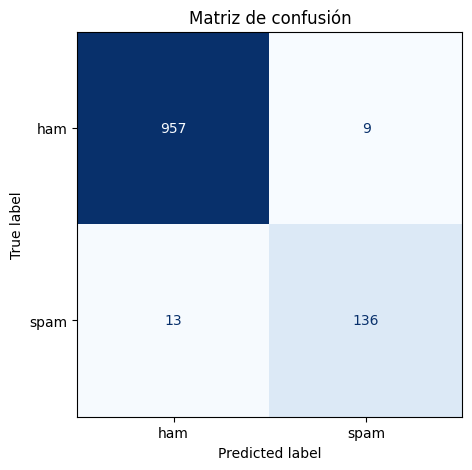

In [13]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión')
plt.show()

## 6. Pruebas rápidas con mensajes nuevos

In [14]:
examples = [
    'Congratulations, you have won a free ticket. Call now.',
    'Hi, are we still meeting for lunch today?',
    'Free entry in a weekly competition. Text WIN to 80086 now.',
]

clean_examples = [preprocess_text(text) for text in examples]
example_vectors = vectorizer.transform(clean_examples)
example_predictions = model.predict(example_vectors)

pd.DataFrame({
    'message': examples,
    'prediction': example_predictions,
})

,message,prediction
0,"Congratulations, you have won a free ticket. Call now.",spam
1,"Hi, are we still meeting for lunch today?",ham
2,Free entry in a weekly competition. Text WIN to 80086 now.,spam


## Conclusión
La solución cumple con los requisitos del ejercicio:

- Carga del dataset desde ruta absoluta `/workspace/spam.csv` como ruta principal.
- Limpieza y renombrado de columnas.
- Preprocesamiento del texto.
- Vectorización con TF-IDF y máximo de 5000 características.
- División 80/20 con `train_test_split`.
- Entrenamiento de un modelo de clasificación.
- Evaluación con accuracy, precision, recall, F1-score y matriz de confusión.